## Regresión Lineal

In [2]:
# Imports necesarios
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
plt.rcParams['figure.figsize'] = (16, 9)
plt.style.use('ggplot')
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
#datos de entrada
data = pd.read_csv("C:/Users/nana_/OneDrive/Desktop/UNAD/2025/Dataset Regresión Lineal/car details v4.csv")
#veamos cuantas dimensiones y registros contiene
data.shape

(2059, 20)

In [6]:
data.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [8]:
data.describe()

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.059000e+03,2059.000000,2.059000e+03,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000
mean,1.702992e+06,2016.425449,5.422471e+04,4280.860652,1767.991980,1591.735338,5.306266,52.002210
std,2.419881e+06,3.363564,5.736172e+04,442.458507,135.265825,136.073956,0.822170,15.110198
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,4.849990e+05,2014.000000,2.900000e+04,3985.000000,1695.000000,1485.000000,5.000000,41.250000
50%,8.250000e+05,2017.000000,5.000000e+04,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,1.925000e+06,2019.000000,7.200000e+04,4629.000000,1831.500000,1675.000000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


In [43]:
# Valores nulos
print("Valores faltantes por columna:")
print(data.isnull().sum())

Valores faltantes por columna:
Make                    0
Model                   0
Price                   0
Year                    0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64


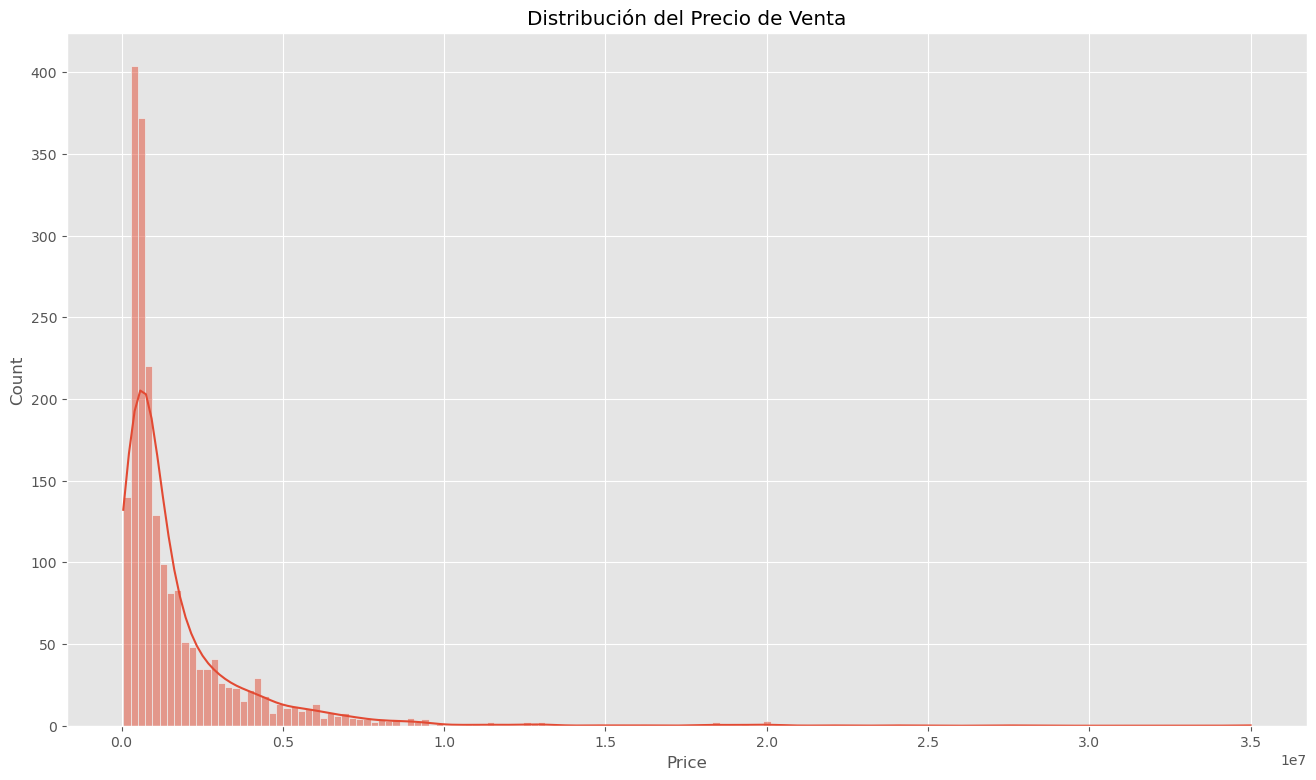

In [50]:
# Histograma de precio
sns.histplot(data['Price'], kde=True)
plt.title("Distribución del Precio de Venta")
plt.show()

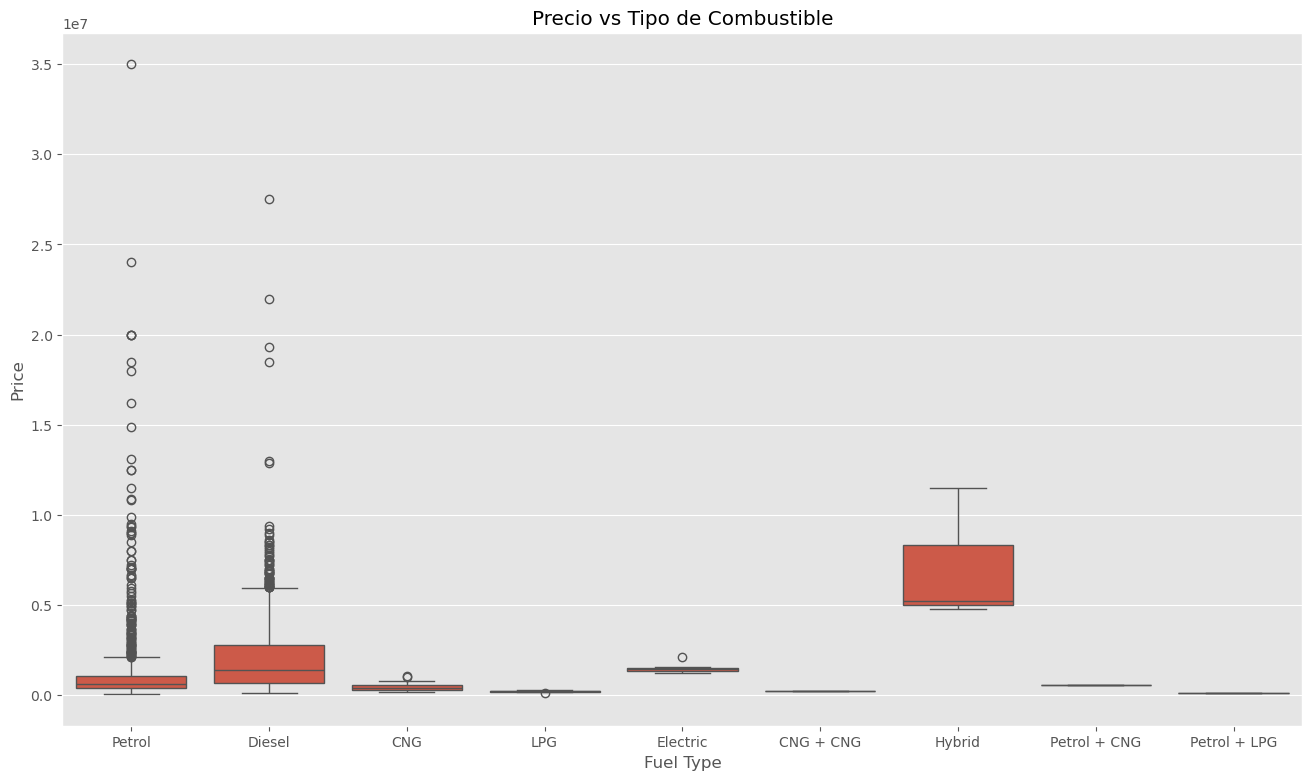

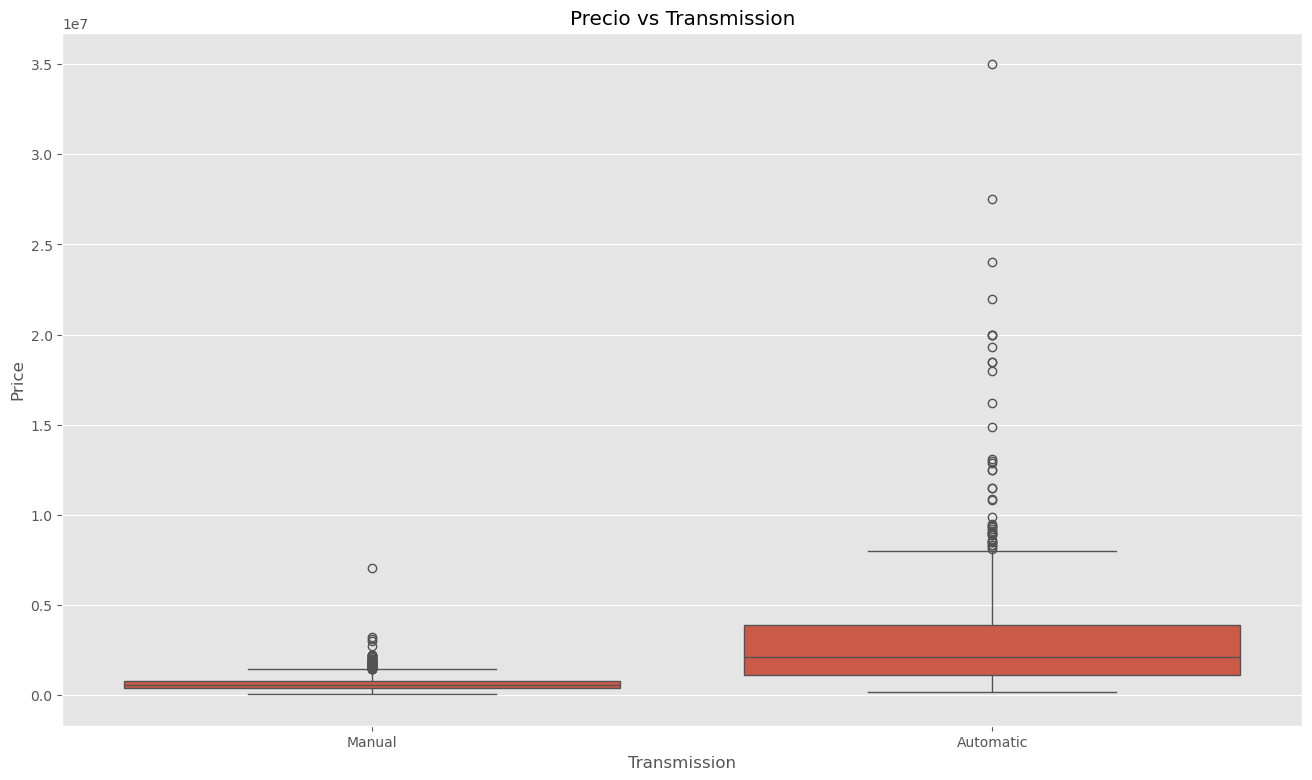

In [54]:
# Boxplot de precios por tipo de combustible
sns.boxplot(data, x='Fuel Type', y='Price')
plt.title("Precio vs Tipo de Combustible")
plt.show()

# Boxplot por tipo de transmisión
sns.boxplot(data, x='Transmission', y='Price')
plt.title("Precio vs Transmission")
plt.show()

In [70]:
# valores faltantes en cada columna
print("Valores faltantes en cada columna:")
print(data.isnull().sum())

# Si la cantidad de registros con valores faltantes es muy baja, puedes eliminarlos:
df_clean = data.dropna()

# Eliminar registros duplicados (si existen)
print("Número de registros duplicados antes:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()
print("Número de registros duplicados después:", df_clean.duplicated().sum())

Valores faltantes en cada columna:
Make                    0
Model                   0
Price                   0
Year                    0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64
Número de registros duplicados antes: 0
Número de registros duplicados después: 0


In [72]:
# Conversión de tipos para variables numéricas:
# Las columnas "year", "price" y "Kilometer" deben ser numéricas.
df_clean['Year'] = pd.to_numeric(df_clean['Year'], errors='coerce')
df_clean['Price'] = pd.to_numeric(df_clean['Price'], errors='coerce')
df_clean['Kilometer'] = pd.to_numeric(df_clean['Kilometer'], errors='coerce')

# Verifica si la conversión generó valores nulos y elimina aquellos registros.
df_clean = df_clean.dropna(subset=['Year', 'Price', 'Kilometer'])

# Transformar variables categóricas en variables dummy
# Convertiremos las columnas: 'Width', 'seller_type', 'transmission' y 'owner'
df_encoded = pd.get_dummies(df_clean, columns=['Width', 'Seller Type', 'Transmission', 'Owner'], drop_first=True)

# Revisar el dataframe preprocesado
print("Datos preprocesados listos:")
print(df_encoded.head())

Datos preprocesados listos:
            Make                            Model    Price  Year  Kilometer  \
0          Honda              Amaze 1.2 VX i-VTEC   505000  2017      87150   
1  Maruti Suzuki                  Swift DZire VDI   450000  2014      75000   
2        Hyundai             i10 Magna 1.2 Kappa2   220000  2011      67000   
3         Toyota                         Glanza G   799000  2019      37500   
4         Toyota  Innova 2.4 VX 7 STR [2016-2020]  1950000  2018      69000   

  Fuel Type   Location   Color   Engine           Max Power  ... Width_2157.0  \
0    Petrol       Pune    Grey  1198 cc   87 bhp @ 6000 rpm  ...        False   
1    Diesel   Ludhiana   White  1248 cc   74 bhp @ 4000 rpm  ...        False   
2    Petrol    Lucknow  Maroon  1197 cc   79 bhp @ 6000 rpm  ...        False   
3    Petrol  Mangalore     Red  1197 cc   82 bhp @ 6000 rpm  ...        False   
4    Diesel     Mumbai    Grey  2393 cc  148 bhp @ 3400 rpm  ...        False   

  Width_21

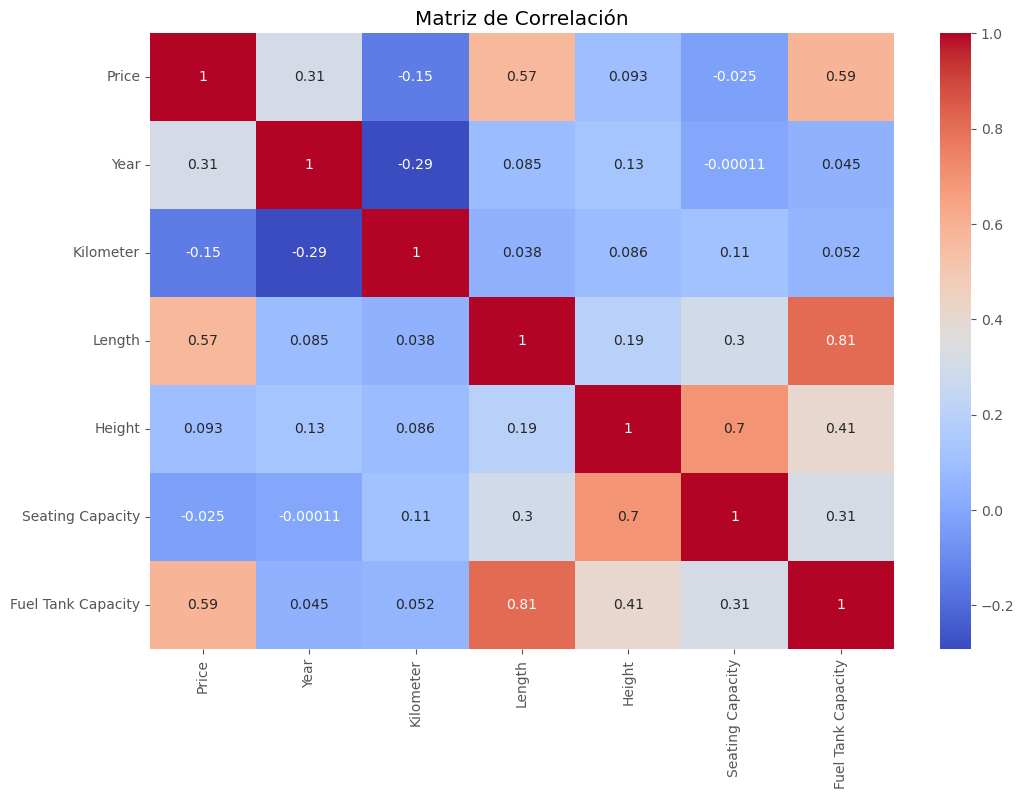

Correlación con Price:
Price                 1.000000
Fuel Tank Capacity    0.586109
Length                0.568875
Year                  0.309381
Height                0.092968
Seating Capacity     -0.024879
Kilometer            -0.147276
Name: Price, dtype: float64


In [76]:
# Eliminar columnas no numéricas
df_corr = df_encoded.select_dtypes(include=['int64', 'float64'])

# Ahora sí podemos calcular la matriz de correlación
plt.figure(figsize=(12, 8))
correlation = df_corr.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Matriz de Correlación")
plt.show()

# Ver correlación con la variable objetivo
correlation_target = correlation['Price'].sort_values(ascending=False)
print("Correlación con Price:")
print(correlation_target)

In [80]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_regression

# Copia limpia del dataframe
df_model = df_encoded.copy()

# Eliminar columnas no numéricas o poco útiles para predicción
columnas_a_eliminar = ['Make', 'Model', 'Max Power', 'Max Torque', 'Location', 'Color', 'Drivetrain']
df_model.drop(columns=[col for col in columnas_a_eliminar if col in df_model.columns], inplace=True)

# Asegurar que la columna objetivo está presente y no tiene valores faltantes
df_model = df_model[df_model['Price'].notna()]

# Definir X (predictoras) y y (variable objetivo)
X = df_model.drop('Price', axis=1)
y = df_model['Price']

# Convertir todas las variables categóricas a numéricas (one-hot encoding)
X = pd.get_dummies(X, drop_first=True)

# Confirmamos que todas son numéricas
print("Columnas numéricas de X:", X.columns.tolist())

# Seleccionar las mejores características
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X, y)

# Mostrar puntuaciones
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False)

print("Ranking de características relevantes:")
print(feature_scores)

Columnas numéricas de X: ['Year', 'Kilometer', 'Length', 'Height', 'Seating Capacity', 'Fuel Tank Capacity', 'Width_1490.0', 'Width_1495.0', 'Width_1500.0', 'Width_1515.0', 'Width_1520.0', 'Width_1525.0', 'Width_1550.0', 'Width_1560.0', 'Width_1579.0', 'Width_1595.0', 'Width_1600.0', 'Width_1620.0', 'Width_1635.0', 'Width_1642.0', 'Width_1645.0', 'Width_1647.0', 'Width_1660.0', 'Width_1665.0', 'Width_1670.0', 'Width_1677.0', 'Width_1680.0', 'Width_1682.0', 'Width_1683.0', 'Width_1687.0', 'Width_1690.0', 'Width_1694.0', 'Width_1695.0', 'Width_1698.0', 'Width_1699.0', 'Width_1700.0', 'Width_1704.0', 'Width_1706.0', 'Width_1710.0', 'Width_1715.0', 'Width_1722.0', 'Width_1726.0', 'Width_1727.0', 'Width_1729.0', 'Width_1730.0', 'Width_1734.0', 'Width_1735.0', 'Width_1742.0', 'Width_1745.0', 'Width_1748.0', 'Width_1750.0', 'Width_1755.0', 'Width_1758.0', 'Width_1760.0', 'Width_1764.0', 'Width_1765.0', 'Width_1770.0', 'Width_1775.0', 'Width_1777.0', 'Width_1780.0', 'Width_1783.0', 'Width_1785

In [88]:
from sklearn.linear_model import LinearRegression

# modelo simple
model = LinearRegression()
model.fit(X, y)

# Ver importancia de cada variable (coeficientes absolutos)
importance = pd.DataFrame({'Feature': X.columns, 'Importance': abs(model.coef_)}).sort_values(by='Importance', ascending=False)

print("Importancia de características según regresión lineal:")
print(importance)

Importancia de características según regresión lineal:
            Feature    Importance
167    Width_2220.0  1.941651e+07
266  Engine_3902 cc  1.582037e+07
133    Width_1952.0  1.582037e+07
267  Engine_3982 cc  1.158128e+07
274  Engine_6592 cc  8.398225e+06
..              ...           ...
192  Engine_1353 cc  1.313739e+04
138    Width_1970.0  2.963827e+03
2            Length  7.952257e+02
3            Height  5.752972e+02
1         Kilometer  6.376741e-01

[283 rows x 2 columns]


In [90]:
from sklearn.model_selection import train_test_split

# Dividir el conjunto en 80% train y 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificamos tamaños
print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

Tamaño del conjunto de entrenamiento: (1499, 283)
Tamaño del conjunto de prueba: (375, 283)


In [92]:
from sklearn.linear_model import LinearRegression

# Crear el modelo
modelo = LinearRegression()

# Entrenar el modelo con los datos de entrenamiento
modelo.fit(X_train, y_train)

# Mostrar coeficientes y la intersección (bias)
print("Coeficientes:", modelo.coef_)
print("Intercepción:", modelo.intercept_)

Coeficientes: [ 1.69173761e+05 -4.84740844e-01  7.86073389e+02 -3.30063341e+02
 -1.78713429e+05  8.01681025e+03 -5.66529093e+05 -1.14178862e+05
  2.03051400e+05 -1.17830946e+06 -9.53672560e+05  3.81560980e+05
  3.51779669e+04 -1.20972672e+05 -3.00762213e+05  5.74592440e+05
 -3.36238626e+05 -6.50227420e+05 -6.05125093e+05 -9.44061679e+03
 -7.25583444e+05 -3.39615473e+05 -3.35176689e+05 -4.64517212e+05
 -2.96160009e+05 -6.54656963e+05 -3.01500527e+05 -1.89060198e+05
  8.19714476e+04 -4.41002823e+05 -7.63891613e+02 -1.89299258e+05
 -3.10139740e+05 -2.45100272e+04 -5.64917212e+05 -8.08387333e+05
 -1.30797853e-05 -8.72183414e+05 -8.64264027e+04  2.54171980e+05
  2.33489554e-05 -3.97904495e+05  1.20050435e+06 -1.05847818e+06
 -9.58779191e+05 -3.89321447e+05 -6.43277632e+05 -6.52432988e+05
 -4.28021849e+05 -1.23281228e+06  1.72521877e+05 -7.71827178e+05
 -8.40858977e+05 -3.88272276e+05 -4.57016632e+04 -3.67226735e+05
 -8.29487662e+05 -8.95292178e+05 -4.02424967e+05 -7.52797421e+05
 -2.1874411

In [94]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predicciones del modelo
y_pred = modelo.predict(X_test)

# Evaluación
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print( "Evaluación del Modelo de Regresión:")
print("MAE  (Error Absoluto Medio):", round(mae, 2))
print("MSE  (Error Cuadrático Medio):", round(mse, 2))
print("RMSE (Raíz del MSE):", round(rmse, 2))
print("R²   (Coeficiente de Determinación):", round(r2, 4))

Evaluación del Modelo de Regresión:
MAE  (Error Absoluto Medio): 693110.75
MSE  (Error Cuadrático Medio): 6571291197019.66
RMSE (Raíz del MSE): 2563452.98
R²   (Coeficiente de Determinación): 0.4387


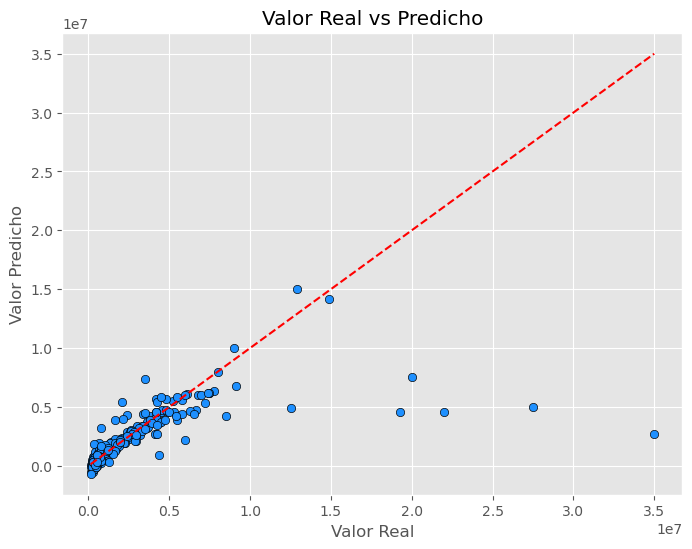

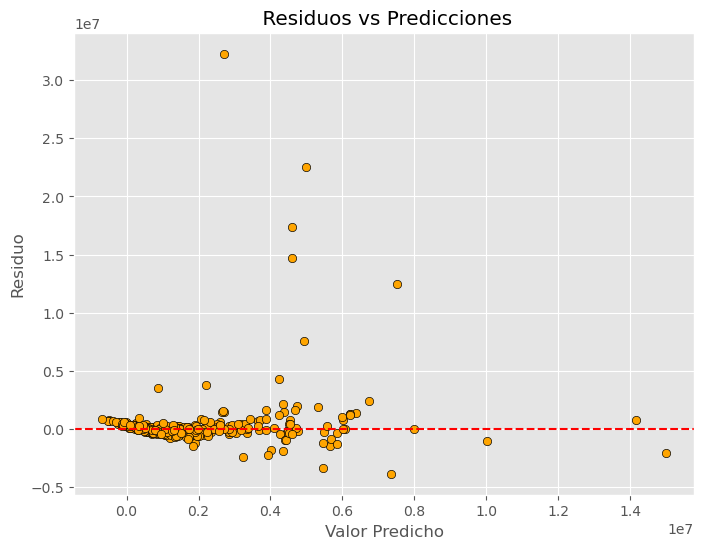

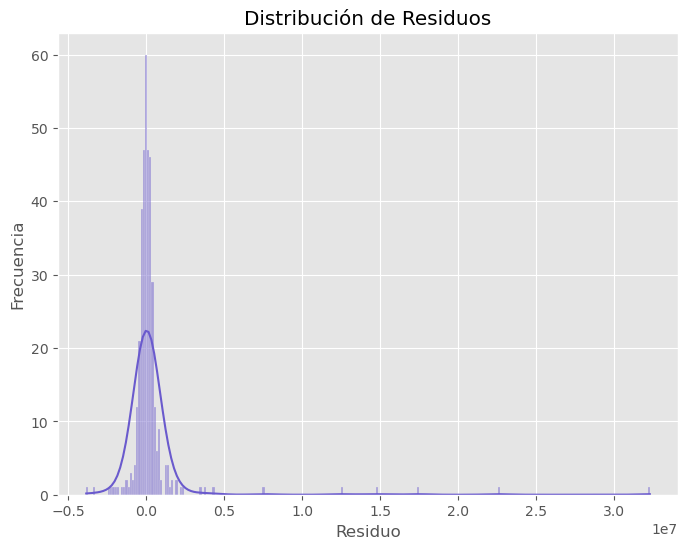

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='dodgerblue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # línea ideal
plt.xlabel("Valor Real")
plt.ylabel("Valor Predicho")
plt.title("Valor Real vs Predicho")
plt.grid(True)
plt.show()

residuos = y_test - y_pred

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuos, color='orange', edgecolor='k')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valor Predicho")
plt.ylabel("Residuo")
plt.title(" Residuos vs Predicciones")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(residuos, kde=True, color='slateblue')
plt.title("Distribución de Residuos")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

## Interpretar, analizar y documentar los resultados obtenidos.